<a href="https://colab.research.google.com/github/sofimargo/Modelado-y-Simulaci-n-de-Sistemas-Mecatr-nicos/blob/main/AF5_MySdeSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF5 Simulación de un sistema a partir de ecuaciones de Euler Lagrange
## 001 V1-V3
- Saul Eduardo Torres Hernández 2120940
- Sofía Alejandra Martínez Gómez 1998005
- Suri Astrid Vallejo Fernández 2120638
- Edder Mauricio Lopez Ceniceros 2031095



In [15]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [16]:
#Definimos parámetros
def f(t, x):
  Ir = 0.16
  m = 5
  g = 9.81
  lc = 0.01
  b = 0.14
  fc = 0.45
  # Vector de Estados (Entrada)
  q = x[0]   # Posición
  qp = x[1]  # Velocidad

  # Torque de entrada (motor)
  tau_motor = tau(t)

  # Modelo de Fricción de Coulomb
  # El signo negativo indica que la fricción se opone al movimiento.
  friccion_coulomb = fc * np.tanh(100000 * qp)

  # Cálculo de la aceleración articular (qpp)
  qpp = (1/Ir) * (tau_motor - m*g*lc*np.sin(q) - b*qp - friccion_coulomb)

  # Vector de Salida (Derivada del Estado)
  dxdt = [qp, qpp]

  return dxdt

#Función para el Torque de Entrada
def tau(t):
    return 1.5 * np.sin(t)

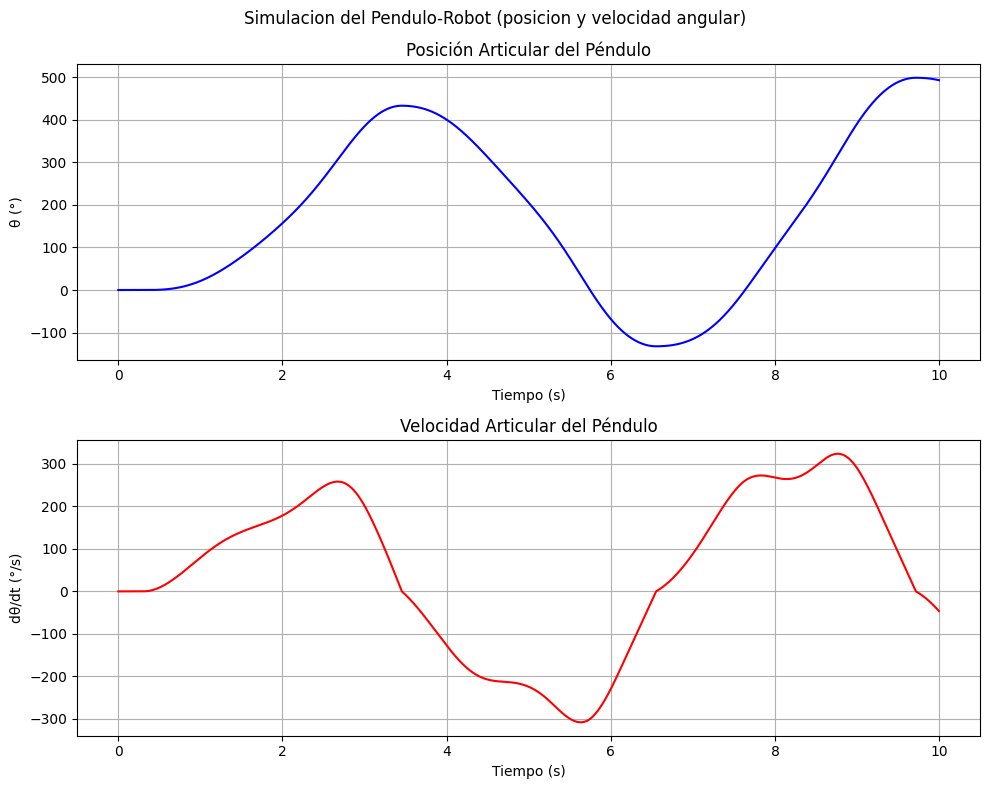

In [22]:
# 1. Parámetros de Simulación
ti = 0.0
tf = 10.0    # Tiempo final (s)
h = 0.0025
ts = np.arange(ti, tf, h)

# Condiciones Iniciales
q0 = 0.0
qp0 = 0.0
x0 = [q0, qp0]

# Resolución de la Ecuación Diferencial
sol = solve_ivp(f, [ti, tf], x0, t_eval=ts)

# Extraemos los resultados
t = sol.t
posicion = sol.y[0]
velocidad = sol.y[1]

# Procesamiento y Gráficas de Resultados
posicion_grados = np.rad2deg(posicion)
velocidad_grados = np.rad2deg(velocidad)

# Crear la figura y los ejes (subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Gráfica de Posición
ax1.plot(t, posicion_grados, 'b-', label='Posición (q)')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Posición Articular del Péndulo')
ax1.grid(True)

# Gráfica de Velocidad
ax2.plot(t, velocidad_grados, 'r-', label='Velocidad (qp)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('dθ/dt (°/s)')
ax2.set_title('Velocidad Articular del Péndulo')
ax2.grid(True)

plt.suptitle('Simulacion del Pendulo-Robot (posicion y velocidad angular)')
plt.tight_layout()